Run this locally using docker. The instructions are [here](https://research.google.com/colaboratory/local-runtimes.html).

Step 1:
[Install docker](https://docs.docker.com/get-docker/).

Step 2:
Then from command line execute the following code:
```
docker run --gpus=all -p 127.0.0.1:9000:8080 us-docker.pkg.dev/colab-images/public/runtime
```
Once the container has started, it will print a message with the initial backend URL used for authentication, of the form 'http://127.0.0.1:9000/?token=...'.

Step3:
In Colab, click the "Connect" button and select "Connect to local runtime...". Enter the URL from the previous step in the dialog that appears and click the "Connect" button. After this, you should now be connected to your local runtime.


In [ ]:
!pip install ambiance

In [ ]:
from ambiance import Atmosphere
import jax.numpy as jnp
import numpy as np
import jax
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from abc import abstractmethod
from typing import List

In [ ]:
g0_mps2 = 9.80665


## Aircraft State

We are considering 3 DoF in FRD frame:
*   $M$: Mach number
*   $\alpha$: angle of attack
*   $\gamma$: flight path angle
*   $z$: altitude

Some properties are computed internally
*   $\theta$: pitch angle as $\theta = \alpha + \gamma$
*   $\rho$: density
*   $a$: speed of sound
*   $V$: true airspeed as $V=Ma$
*   $q$: dynamic pressure as $0.5 \rho V^2 $


In [ ]:
class AircraftState:
  def __init__(self):
    self.M = 0.
    self.gamma_deg = 0
    self.alpha_deg = 0
    self.z_m = 0.
    return

  @property
  def rho_kgpm3(self):
    atmos = Atmosphere(self.z_m)
    return atmos.density[0]

  @property
  def a_mps(self):
    atmos = Atmosphere(self.z_m)
    return atmos.speed_of_sound[0]

  @property
  def theta_deg(self):
    return self.alpha_deg + self.gamma_deg

  @property
  def V_mps(self):
    return self.a_mps * self.M

  @property
  def q_Npms2(self):
    return 0.5*self.rho_kgpm3*self.V_mps**2


## Aerodynamic Model



In [ ]:
class F16AppmModel:
  def __init__(self):

    self.wing_ar = 3
    self.e = 0.9086

    self.CD0_subsonic = 0.0243
    self.CD0_supersonic_level = 0.0368
    self.CD0_supersonic_turn = 0.0412

    self.CD0_transonic = 0.0202

    self.k1_subsonic = 0.121
    self.k1_supersonic_level = 0.321
    self.k1_supersonic_turn = 0.169

    self.k2 = 0

    self.CLmax_stall = 1.0
    self.CLmax_takeoff = 1.27
    self.CLmax_landing = 1.43

    self.sfc_cruise = 0.0002222
    self.sfc_dash = 0.000683333
    return

  def compute_alpha(self, state: AircraftState):
    rho_kgpm3 = state.rho_kgpm3
    rho0_kgpm3 = 1.225
    M = state.M
    alpha = rho_kgpm3/rho0_kgpm3*(1+0.7*M)
    return alpha


  def compute_LbyD(self, state: AircraftState, WbyS_Npm2: float):
    q_Npms2 = state.q_Npms2

    if state.M < 0.3:
      CD0 = self.CD0_subsonic
    elif state.M < 1.0:
      CD0 = self.CD0_transonic
    else:
      CD0 = self.CD0_supersonic_level

    LbyD = 1 / ( (q_Npms2*CD0/WbyS_Npm2) + (WbyS_Npm2/(q_Npms2*jnp.pi*self.e*self.wing_ar)) )

    # print('** DEBUG **')
    # print('Inside L/D calc')
    # print('q:', q_Npms2)
    # print('CD0:', CD0)
    # print('WbyS_Npm2:', WbyS_Npm2)
    # print('e:', self.e)
    # print('ar:', self.wing_ar)
    # print('L/D:', LbyD)
    # print('************')
    return LbyD

  def compute_fm(self, state: AircraftState):
    return

appm_model = F16AppmModel()

Wto_F16_kg = 32737
TbyW_design_Npkg = 0.98
WbyS_design_kgpm2 = 428  # kg/m^2

Tsl_F16_N = TbyW_design_Npkg*Wto_F16_kg
Sref_F16_m2 = Wto_F16_kg/WbyS_design_kgpm2

dv_dev_0 = jnp.array([Wto_F16_kg, Tsl_F16_N, Sref_F16_m2])

## Point Performance using Mattingly's Master Equation

$\frac{W_{SL}}{W_{TO}} = \frac{\beta}{\alpha}\left\{ \frac{qS}{\beta W_{TO}} \left( K_1 \left( \frac{n \beta}{q}\frac{W_{TO}}{S} \right)^2 +K_2 \left( \frac{n \beta}{q}\frac{W_{TO}}{S} \right) + C_{D_0} + \frac{R}{qS} \right) + \frac{1}{V} \frac{d}{dt} \left( h + \frac{V^2}{2 g_0} \right) \right\}$

Or

$\frac{T_{SL}}{W_{TO}} = A \frac{1}{\frac{W_{TO}}{S}} + B \left( \frac{W_{TO}}{S} \right) + C + D$

where

$A=\frac{q C_{D_0}}{\alpha}$

$B=\frac{q}{\alpha} K_1 \left( \frac{n \beta}{q} \right)^2$

$C = K_2 n \frac{\beta}{\alpha}$

$D = \frac{\beta}{\alpha} \left\{ \frac{1}{V} \frac{d}{dt} \left( h + \frac{V^2}{2 g_0} \right) \right\}$

In [ ]:
@dataclass
class PointPerformance:

  def __init__(self, state: AircraftState, beta: float):
    self.agl_m = state.z_m
    self.beta = beta
    return

  @property
  @abstractmethod
  def name(self) -> str:
    pass

  @property
  def WbyS_kgpm2(self):
    WbyS_Npm2 = self.compute_WbyS_Npm2()
    return WbyS_Npm2/g0_mps2

  @abstractmethod
  def compute_constraint(self):
    pass


class Only_WbyS(PointPerformance):
  def __init__(self, state: AircraftState, beta: float):
    super().__init__(state, beta)

  @abstractmethod
  def compute_WbyS_Npm2(self):
    pass

  def compute_constraint(self, dv_vec):
    Wto_kg = dv_vec[0]
    Tsl_N = dv_vec[1]
    S_m2 = dv_vec[2]
    WbyS_Npm2 = self.compute_WbyS_Npm2()
    constraint = (Wto_kg*g0_mps2)/S_m2 - WbyS_Npm2
    return constraint


class Only_TbyW(PointPerformance):

  def __init__(self, state: AircraftState, beta: float):
    super().__init__(state, beta)

  @abstractmethod
  def compute_TbyW(self):
    pass


class Both_WbyS_TbyW(PointPerformance):
  def compute_A(self):
    q_Npms2 = self.q_Npms2
    q_kgpms2 = q_Npms2/g0_mps2
    A = q_kgpms2*self.CD0/self.alpha
    return A

  def compute_B(self):
    q_Npms2 = self.q_Npms2
    q_kgpms2 = q_Npms2/g0_mps2
    B = (q_kgpms2/self.alpha)*(self.k1*(self.n*self.beta/q_kgpms2)**2)
    return B

  def compute_C(self):
    C = self.k2*self.n*self.beta/self.alpha
    return C

  @abstractmethod
  def compute_D(self):
    raise NotImplementedError

  def compute_TbyW(self, WbyS_kgpm2):
    TbyW = self.compute_A() / WbyS_kgpm2 + self.compute_B() * WbyS_kgpm2 + self.compute_C() + self.compute_D()
    return TbyW

  def compute_constraint(self, dv_vec):
    Wto_kg = dv_vec[0]
    Tsl_N = dv_vec[1]
    S_m2 = dv_vec[2]

    WbyS = Wto_kg/S_m2
    TbyW_actual = Tsl_N/(Wto_kg)

    TbyW_necessary = self.compute_TbyW(WbyS)
    constraint = TbyW_necessary - TbyW_actual
    return constraint

  def __init__(self, state: AircraftState, beta: float):
    super().__init__(state, beta)

### Stall

$\frac{W_{TO}}{S}=\frac{1}{2} \rho V^2 C_{L_{max}}$

In [ ]:
class Stall(Only_WbyS):
  def __init__(self, state: AircraftState, appm_model, beta: float):
    super().__init__(state, beta)
    self.V_mps = state.V_mps
    self.rho_kgpm3 = state.rho_kgpm3
    self.CLmax = appm_model.CLmax_stall
    return

  def compute_WbyS_Npm2(self):
    WbyS_Npm2 = 0.5*self.rho_kgpm3*self.V_mps**2 * self.CLmax
    return WbyS_Npm2

  @property
  def name(self):
    return "Stall"

In [ ]:
# Stall Requirement
state_stall = AircraftState()

state_stall.z_m = 0.  # At sea level

atmos = Atmosphere(state_stall.z_m)
a_mps = atmos.speed_of_sound[0]
V_mps = 300*0.27777778  # 300 kmph
state_stall.M = V_mps/a_mps

pp_stall = Stall(state=state_stall, appm_model=appm_model,
                 beta=1.0)

# Testing JAX
f = pp_stall.compute_constraint
dfdV = jax.jit(jax.grad(f))

# Pre-compile the function
dfdV(dv_dev_0).block_until_ready()

print(f(dv_dev_0))
print(dfdV)
print(dfdV(dv_dev_0))

-56.226074
<PjitFunction of <function Only_WbyS.compute_constraint at 0x7ec6004acca0>>
[  0.12821108   0.         -54.874344  ]


### Turn

$p$ is the bank rate, $R_c$ is the turning radius, $\phi$ the bank angle.

For a turn at constant altitude, $L = \frac{1}{\cos{\phi}} W$

Recall, $L = n W$

Then, $n= \sqrt{\left( \frac{pV}{g_0} \right)^2 + 1}$ or $n= \sqrt{\left( \frac{V^2}{g_0 R} \right)^2 + 1}$


### Subsonic Turn

*   Clean configuration: $R=0$
*   Constant altitute: $\frac{dh}{dt}=0$
*   Constant speed: $\frac{dV}{dt}=0$

$\frac{T_{SL}}{W_{TO}} = A \frac{1}{\frac{W_{TO}}{S}} + B \left( \frac{W_{TO}}{S} \right) $

In [ ]:
class SubsonicTurn(Both_WbyS_TbyW):
  def __init__(self, state: AircraftState, appm_model,
               beta: float,
               n: float):
    super().__init__(state, beta)

    self.q_Npms2 = state.q_Npms2
    self.CD0 = appm_model.CD0_subsonic
    self.k1 = appm_model.k1_subsonic
    self.k2 = appm_model.k2
    self.alpha = appm_model.compute_alpha(state)
    self.n = n
    return

  @property
  def name(self):
    return "Subsonic Turn"

  def compute_D(self):
    return 0.

In [ ]:
# Subsonic Turn Requirement
state_subsonic_turn = AircraftState()

state_subsonic_turn.z_m = 1500.
state_subsonic_turn.M = 0.9

pp_subsonic_turn = SubsonicTurn(state=state_subsonic_turn, appm_model=appm_model,
                                beta=0.8, n=9.)
A = pp_subsonic_turn.compute_A()
B = pp_subsonic_turn.compute_B()
C = pp_subsonic_turn.compute_C()
D = pp_subsonic_turn.compute_D()

WbyS_list = np.linspace(start=100, stop=550, num=10)
TbyW_Npkg = pp_subsonic_turn.compute_TbyW(WbyS_kgpm2=WbyS_list)

# Testing JAX
f = pp_subsonic_turn.compute_constraint

dfdV = jax.jit(jax.grad(f))

# Pre-compile the function
dfdV(dv_dev_0).block_until_ready()
print(f(dv_dev_0))
print(dfdV)
print(dfdV(dv_dev_0))

-0.39282352
<PjitFunction of <function Both_WbyS_TbyW.compute_constraint at 0x7ec6004ac430>>
[ 3.5826932e-05 -3.0546478e-05 -2.5215128e-03]


### Excess Power or Horizontal Acceleration

*   Clean configuration: $R=0$
*   Level flight: $n ≈ 1$ and $\frac{dh}{dt}=0$

Excess power, $P_s = \frac{d}{dt} \left( \frac{V^2}{2 g_0} \right)$

$D=\frac{\beta}{\alpha} \frac{P_s}{V}$

$\frac{T_{SL}}{W_{TO}} = A \frac{1}{\frac{W_{TO}}{S}} + B \left( \frac{W_{TO}}{S} \right) + D$

In [ ]:
class ExcessPower(Both_WbyS_TbyW):
  def __init__(self, state: AircraftState, appm_model,
               beta: float,
               n: float,
               Ps_mps: float):
    super().__init__(state, beta)

    self.q_Npms2 = state.q_Npms2
    self.CD0 = appm_model.CD0_subsonic
    self.k1 = appm_model.k1_subsonic
    self.k2 = appm_model.k2
    self.alpha = appm_model.compute_alpha(state)
    self.n = n
    self.Ps_mps = Ps_mps
    self.V_mps = state.V_mps
    return

  def compute_D(self):
    D = (self.beta/self.alpha)*(self.Ps_mps/self.V_mps)
    return D

  @property
  def name(self):
    return "Excess power"

In [ ]:
# Excess Power Requirement
state_excess_power = AircraftState()

state_excess_power.z_m = 1500.
state_excess_power.M = 0.9

pp_excess_power = ExcessPower(state=state_excess_power, appm_model=appm_model,
                               beta=0.8, n=1., Ps_mps=150)
A = pp_excess_power.compute_A()
B = pp_excess_power.compute_B()
C = pp_excess_power.compute_C()
D = pp_excess_power.compute_D()

WbyS_list = np.linspace(start=100, stop=550, num=10)
TbyW_Npkg = pp_excess_power.compute_TbyW(WbyS_kgpm2=WbyS_list)

# Testing JAX
f = pp_excess_power.compute_constraint

dfdV = jax.jit(jax.grad(f))

# Pre-compile the function
dfdV(dv_dev_0).block_until_ready()
print(f(dv_dev_0))
print(dfdV)
print(dfdV(dv_dev_0))

-0.49490544
<PjitFunction of <function Both_WbyS_TbyW.compute_constraint at 0x7ec5ff319240>>
[ 2.4060239e-05 -3.0546478e-05  2.5146329e-03]


### Supersonic Combat Turn

*   Clean configuration: $R=0$
*   Constant altitute: $\frac{dh}{dt}=0$
*   Constant speed: $\frac{dV}{dt}=0$

$\frac{T_{SL}}{W_{TO}} = A \frac{1}{\frac{W_{TO}}{S}} + B \left( \frac{W_{TO}}{S} \right) $

Here, we need to use the drag coefficients for supersonic flight

In [ ]:
class SupersonicTurn(Both_WbyS_TbyW):
  def __init__(self, state: AircraftState, appm_model,
               beta: float,
               n: float):
    super().__init__(state, beta)

    self.q_Npms2 = state.q_Npms2
    self.CD0 = appm_model.CD0_supersonic_turn
    self.k1 = appm_model.k1_supersonic_turn
    self.k2 = appm_model.k2
    self.alpha = appm_model.compute_alpha(state)
    self.n = n
    return

  @property
  def name(self):
    return "Supersonic Turn"

  def compute_D(self):
    return 0.

In [ ]:
# Supersonic Turn Requirement
state_supersonic_turn = AircraftState()

state_supersonic_turn.z_m = 9000.
state_supersonic_turn.M = 1.2

pp_supersonic_turn = SupersonicTurn(state=state_supersonic_turn, appm_model=appm_model,
                                 beta=0.8, n=4.)
A = pp_supersonic_turn.compute_A()
B = pp_supersonic_turn.compute_B()
C = pp_supersonic_turn.compute_C()
D = pp_supersonic_turn.compute_D()

WbyS_list = np.linspace(start=100, stop=550, num=10)
TbyW_Npkg = pp_supersonic_turn.compute_TbyW(WbyS_kgpm2=WbyS_list)

# Testing JAX
f = pp_supersonic_turn.compute_constraint

dfdV = jax.jit(jax.grad(f))

# Pre-compile the function
dfdV(dv_dev_0).block_until_ready()
print(f(dv_dev_0))
print(dfdV)
print(dfdV(dv_dev_0))

-0.21211088
<PjitFunction of <function Both_WbyS_TbyW.compute_constraint at 0x7ec5ff319900>>
[ 2.6852680e-05 -3.0546478e-05  1.3194672e-03]


### Instantaneous Turn

*   List
*   List item

$\frac{W_{TO}}{S}=\frac{q}{\beta} \frac{C_{L_{max}}}{n}$


In [ ]:
class InstantaneousTurn(Only_WbyS):
  def __init__(self, state: AircraftState, appm_model,
               beta: float, turn_rate_degps: float):
    super().__init__(state, beta)
    self.q_Npms2 = state.q_Npms2
    self.beta = beta
    self.rho_kgpm3 = state.rho_kgpm3
    self.CLmax = appm_model.CLmax_stall

    V_mps = state.V_mps
    self.n = np.sqrt( ( (turn_rate_degps*0.0174532925)*V_mps/9.81 )**2 + 1 )
    return

  def compute_WbyS_Npm2(self):
    WbyS_Npm2 = (self.q_Npms2/self.beta) * (self.CLmax/self.n)
    return WbyS_Npm2

  @property
  def name(self):
    return "Instantaneous Turn"

In [ ]:
# Instantaneous Turn Requirement
state_instantaneous_turn = AircraftState()

state_instantaneous_turn.z_m = 6000.
state_instantaneous_turn.M = 0.9
beta_instantaneous_turn = 0.5844444444  # Weight with 50% fuel + missiles + gun
pp_instantaneous_turn = InstantaneousTurn(
    state=state_instantaneous_turn, appm_model=appm_model,
    beta=beta_instantaneous_turn, turn_rate_degps=18
    )

WbyS_kgpm2 = pp_instantaneous_turn.WbyS_kgpm2

# Testing JAX
f = pp_instantaneous_turn.compute_constraint
dfdV = jax.jit(jax.grad(f))

# Pre-compile the function
dfdV(dv_dev_0).block_until_ready()
print(f(dv_dev_0))
print(dfdV)
print(dfdV(dv_dev_0))

-795.25635
<PjitFunction of <function Only_WbyS.compute_constraint at 0x7ec5ff31a320>>
[  0.12821108   0.         -54.874344  ]


### Dash

*   Clean configuration: $R=0$
*   Constant altitute: $\frac{dh}{dt}=0$
*   Constant speed: $\frac{dV}{dt}=0$

$\frac{T_{SL}}{W_{TO}} = A \frac{1}{\frac{W_{TO}}{S}} + B \left( \frac{W_{TO}}{S} \right) $

Here, we need to use
* The drag coefficients for supersonic flight
* Maneuver $\beta$
* $n=1$


In [ ]:
class Dash(Both_WbyS_TbyW):
  def __init__(self, state: AircraftState, appm_model,
               beta: float,
               n: float):
    super().__init__(state, beta)

    self.q_Npms2 = state.q_Npms2
    self.CD0 = appm_model.CD0_supersonic_level
    self.k1 = appm_model.k1_supersonic_level
    self.k2 = appm_model.k2
    self.alpha = appm_model.compute_alpha(state)
    self.n = n
    return

  @property
  def name(self):
    return "Dash"

  def compute_D(self):
    return 0.

In [ ]:
# Dash Requirement
state_dash = AircraftState()

state_dash.z_m = 20000.
state_dash.M = 2

pp_dash = Dash(state=state_dash, appm_model=appm_model,
               beta=0.5844444444,  # Weight with 50% fuel + missiles + gun
               n=1.)

A = pp_dash.compute_A()
B = pp_dash.compute_B()
C = pp_dash.compute_C()
D = pp_dash.compute_D()

WbyS_list = np.linspace(start=100, stop=550, num=10)
TbyW_Npkg = pp_dash.compute_TbyW(WbyS_kgpm2=WbyS_list)

# Testing JAX
f = pp_dash.compute_constraint

dfdV = jax.jit(jax.grad(f))

# Pre-compile the function
dfdV(dv_dev_0).block_until_ready()
print(f(dv_dev_0))
print(dfdV)
print(dfdV(dv_dev_0))

-0.030082703
<PjitFunction of <function Both_WbyS_TbyW.compute_constraint at 0x7ec5ff31a9e0>>
[ 1.1344392e-05 -3.0546478e-05  7.9570152e-03]


### Climb Rate

*   Clean configuration: $R=0$
*   Constant speed: $\frac{dV}{dt}=0$
*   Thrust lapse rate: $\alpha=1$

Rate of climb, $\dot{h} = \frac{dh}{dt}$

$D=\frac{\beta}{\alpha} \frac{\dot{h}}{V}$

$\frac{T_{SL}}{W_{TO}} = A \frac{1}{\frac{W_{TO}}{S}} + B \left( \frac{W_{TO}}{S} \right) + D$

In [ ]:
class ClimbRate(Both_WbyS_TbyW):
  def __init__(self, state: AircraftState, appm_model,
               beta: float,
               n: float,
               hDot_mps: float):
    super().__init__(state, beta)

    self.q_Npms2 = state.q_Npms2
    self.CD0 = appm_model.CD0_subsonic
    self.k1 = appm_model.k1_subsonic
    self.k2 = appm_model.k2
    self.alpha = 1.
    self.n = n
    self.hDot_mps = hDot_mps
    self.V_mps = state.V_mps
    return

  def compute_D(self):
    D = (self.beta/self.alpha)*(self.hDot_mps/self.V_mps)
    return D

  @property
  def name(self):
    return "Climb rate"

In [ ]:
# Climb Rate Requirement
state_climb_rate = AircraftState()

state_climb_rate.z_m = 0.

atmos = Atmosphere(state_climb_rate.z_m)
a_mps = atmos.speed_of_sound[0]
V_mps = 500*0.51444444  # 500 knots
state_climb_rate.M = V_mps/a_mps

pp_climb_rate = ClimbRate(state=state_climb_rate, appm_model=appm_model,
                          beta=1., n=1., hDot_mps=160)
A = pp_climb_rate.compute_A()
B = pp_climb_rate.compute_B()
C = pp_climb_rate.compute_C()
D = pp_climb_rate.compute_D()

WbyS_list = np.linspace(start=100, stop=550, num=10)
TbyW_Npkg = pp_climb_rate.compute_TbyW(WbyS_kgpm2=WbyS_list)

# Testing JAX
f = pp_climb_rate.compute_constraint

dfdV = jax.jit(jax.grad(f))

# Pre-compile the function
dfdV(dv_dev_0).block_until_ready()
print(f(dv_dev_0))
print(dfdV)
print(dfdV(dv_dev_0))

-0.11081767
<PjitFunction of <function Both_WbyS_TbyW.compute_constraint at 0x7ec5ff31a710>>
[ 2.3151551e-05 -3.0546478e-05  2.9035509e-03]


### Takeoff

*   Thrust is assumed to be much greater than drag: $T_{SL}>> (D+R)$
*   Constant altitude: $\frac{dh}{dt}=0$

Take-off velocity, $V_{TO}=k_{TO}V_{stall}$

where $k_{TO} ≈ 1.2$

$B = \frac{\beta^2}{\alpha} \frac{k_{TO}^2}{\rho C_{L_{max,TO}}} \frac{1}{s_G}$



$\frac{T_{SL}}{W_{TO}} = B \left( \frac{W_{TO}}{S} \right)$

In [ ]:
class Takeoff(Both_WbyS_TbyW):
  def __init__(self, state: AircraftState,
               appm_model,
               beta: float,
               sG_m: float):
    super().__init__(state, beta)

    self.rho_kgpm3 = state.rho_kgpm3
    self.sG_m = sG_m
    self.alpha = 1.
    self.k_TO = 1.2
    self.CLmax = appm_model.CLmax_takeoff
    return

  @property
  def name(self):
    return "Takeoff"

  def compute_A(self):
    return 0.

  def compute_B(self):
    B = (self.beta**2/self.alpha)*(self.k_TO**2/(self.rho_kgpm3*self.CLmax))*(1/self.sG_m)
    return B

  def compute_C(self):
    return 0.

  def compute_D(self):
    return 0.

In [ ]:
# Takeoff Requirement
state_takeoff = AircraftState()
state_takeoff.z_m = 1000.

pp_takeoff = Takeoff(state=state_takeoff, appm_model=appm_model,
                     beta=1., sG_m=1000
                     )
A = pp_takeoff.compute_A()
B = pp_takeoff.compute_B()
C = pp_takeoff.compute_C()
D = pp_takeoff.compute_D()

WbyS_list = np.linspace(start=100, stop=550, num=10)
TbyW_Npkg = pp_takeoff.compute_TbyW(WbyS_kgpm2=WbyS_list)

# Testing JAX
f = pp_dash.compute_constraint

dfdV = jax.jit(jax.grad(f))

# Pre-compile the function
dfdV(dv_dev_0).block_until_ready()
print(f(dv_dev_0))
print(dfdV)
print(dfdV(dv_dev_0))

-0.030082703
<PjitFunction of <function Both_WbyS_TbyW.compute_constraint at 0x7ec5ff31b910>>
[ 1.1344392e-05 -3.0546478e-05  7.9570152e-03]


### Landing

$\frac{W_{TO}}{S} = \frac{s_{FR} \rho C_{L_{max, TD}} \mu}{k_L^2 \beta}$

$\frac{W_{TO}}{S} = \left( \frac{s_{FR}}{t_{FR}k_{TD}} \right)^2 \frac{\rho C_{L_{max, TD}} }{2 \beta}$

In [ ]:
class Landing(Only_WbyS):
  def __init__(self, state: AircraftState,
               appm_model,
               beta: float,
               sFR_m: float,
               mu: float):
    super().__init__(state, beta)

    self.sFR_m = sFR_m
    self.mu = mu

    self.rho_kgpm3 = state.rho_kgpm3
    self.CLmax = appm_model.CLmax_landing
    self.k_L = 1.3
    return

  def compute_WbyS_Npm2(self):
    WbyS_Npm2 = ( ( self.sFR_m*self.rho_kgpm3*self.CLmax*(self.mu* 9.81) )/( self.k_L**2 * self.beta ) )
    return WbyS_Npm2

  @property
  def name(self):
    return "Landing"

In [ ]:
# Landing Requirement
state_landing = AircraftState()
state_landing.z_m = 1000.

pp_landing = Landing(state=state_landing, appm_model=appm_model,
                     beta=1.,  # TODO: This is sus
                     sFR_m=1000, mu=0.5
                     )
WbyS_kgpm2 = pp_landing.WbyS_kgpm2

# Testing JAX
f = pp_landing.compute_constraint
dfdV = jax.jit(jax.grad(f))

# Pre-compile the function
dfdV(dv_dev_0).block_until_ready()

print(f(dv_dev_0))
print(dfdV)
print(dfdV(dv_dev_0))

-416.56934
<PjitFunction of <function Only_WbyS.compute_constraint at 0x7ec5ff318a60>>
[  0.12821108   0.         -54.874344  ]


### Constraint Diagram

In [ ]:
class ConstraintDiagram:

  num_points = 10

  def __init__(self, pp_list: List[PointPerformance], WbyS_range, TbyW_range) -> None:
    self.pp_list = pp_list
    self.WbyS = np.linspace(start=WbyS_range[0], stop=WbyS_range[1], num=self.num_points)
    self.TbyW = np.linspace(start=TbyW_range[0], stop=TbyW_range[1], num=self.num_points)

  def plot(self):
    fig, ax = plt.subplots(1, 1, figsize=(20, 8))

    for pp in self.pp_list:
      if isinstance(pp, Only_WbyS):
        ax.plot(pp.WbyS_kgpm2*np.ones((self.num_points, )), self.TbyW, label=pp.name)
      elif isinstance(pp, Both_WbyS_TbyW):
        TbyW = pp.compute_TbyW(WbyS_kgpm2=self.WbyS)
        ax.plot(self.WbyS, TbyW, label=pp.name)
      else:
        raise NotImplementedError
    ax.set_xlabel('W/s')
    ax.set_ylabel('T/W')
    plt.legend(loc="upper right")
    plt.grid()
    plt.show()
    return

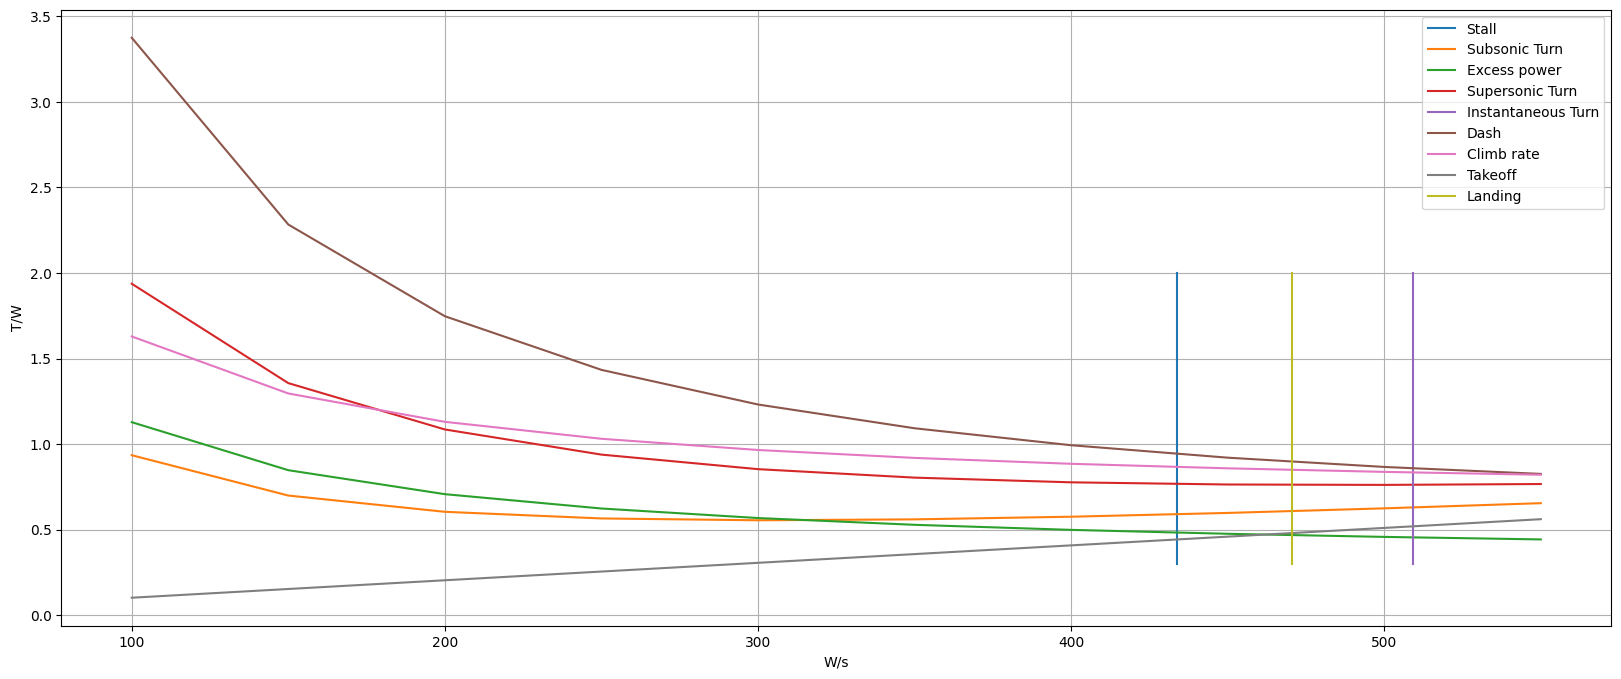

In [ ]:
cd = ConstraintDiagram(
    pp_list=[
        pp_stall,
        pp_subsonic_turn,
        pp_excess_power,
        pp_supersonic_turn,
        pp_instantaneous_turn,
        pp_dash,
        pp_climb_rate,
        pp_takeoff,
        pp_landing
    ],
    WbyS_range=[100, 550],
    TbyW_range=[0.3, 2.]
    )

cd.plot()

In [ ]:
Wto_F16_kg = 32737
TbyW_design_Npkg = 0.98
WbyS_design_kgpm2 = 428

Tsl_F16_N = TbyW_design_Npkg*Wto_F16_kg
Sref_F16_m2 = Wto_F16_kg/WbyS_design_kgpm2

dv_dev_0 = jnp.array([Wto_F16_kg, Tsl_F16_N, Sref_F16_m2])

## Mission Analysis

In [ ]:
class Mission:
  def __init__(self, segments_list, states_list,
               RFF: float = 0.1,
               ) -> None:
    self.segments_list = segments_list
    self.states_list = states_list
    self.RFF = RFF

  def compute_mission_fuel_weight(self,
                                  W_TO_kg: float,
                                  WbyS_design_kgpm2: float,
                                  ):
    Wi_kg = jax.numpy.copy(W_TO_kg)
    fuel_used_kg = 0
    for (segment, state) in zip(self.segments_list, self.states_list):
      # print("Mission segment:", segment.name)
      segment.compute_final_weight(
          Wi_kg=Wi_kg,
          WbyS_design_kgpm2=WbyS_design_kgpm2,
          W_TO_guess_kg=W_TO_kg,
          state=state)
      # print("Fuel weight (kg):", segment.segment_fuel_kg)
      # print("Weight at end of segment (kg):", segment.Wf_kg)
      # print('-----------------------------------')
      fuel_used_kg += segment.segment_fuel_kg
      Wi_kg = segment.Wf_kg

    W_fuel_kg = (1+self.RFF)*fuel_used_kg
    return W_fuel_kg

  def compute_new_W_TO(self,
                       W0_guess_kg: float,
                       W_crew_kg: float,
                       W_fixed_payload_kg: float,
                       W_droped_payload_kg: float,
                       weight_regression,
                       WbyS_design_kgpm2: float):

    WebyW0 = weight_regression.calculate_WebyW0(W_TO_kg=W0_guess_kg)
    # print(WebyW0)

    W_fuel_kg = self.compute_mission_fuel_weight(
        W_TO_kg=W0_guess_kg,
        WbyS_design_kgpm2=WbyS_design_kgpm2
        )
    # print(W_fuel_kg)

    W0 = W_crew_kg + W_fixed_payload_kg + W_droped_payload_kg + W_fuel_kg + (WebyW0 * W0_guess_kg)
    # print(W0)
    return W0

In [ ]:
W_payload_kg = 7575
W_dropable_payload_kg = 1895
W_fixed_payload_kg = 5680

W_crew_kg = 100

### Weight Regression


In [ ]:
class WeightRegression:

  @abstractmethod
  def calculate_WebyW0(self, W_TO_kg):
    raise NotImplementedError


class RaymerFighterAirplaneWeightRegression(WeightRegression):
  def __init__(self,
               TbyW_Npkg: float,
               WbyS_kgpm2: float,
               wing_ar: float,
               mach_max: float) -> None:
    super().__init__()

    self.TbyW_Npkg = TbyW_Npkg
    self.WbyS_kgpm2 = WbyS_kgpm2
    self.wing_ar = wing_ar
    self.mach_max = mach_max

    self.a = -0.02
    self.b = 2.16
    self.C1 = -0.1
    self.C2 = 0.2
    self.C3 = 0.04
    self.C4 = -0.1
    self.C5 = 0.08
    self.Kvs = 1.0

  def calculate_WebyW0(self, W_TO_kg):
    kg2lbs = 2.204

    TbyW = self.TbyW_Npkg/9.80665

    WbyS_Npm2 = self.WbyS_kgpm2*g0_mps2
    WbyS_lbpft2 = WbyS_Npm2*(2.20462/(3.28084**2))

    constant1 = self.a*self.Kvs
    constant2 = ( self.b * self.wing_ar**self.C2 *(TbyW)**self.C3 *(WbyS_lbpft2)**self.C4 * self.mach_max**self.C5  ) * self.Kvs * (kg2lbs)**self.C1
    WebyW0 = constant1 + constant2 * W_TO_kg**self.C1
    return WebyW0

In [ ]:
weight_regression = RaymerFighterAirplaneWeightRegression(
    TbyW_Npkg=TbyW_design_Npkg,
    WbyS_kgpm2=WbyS_design_kgpm2,
    wing_ar=appm_model.wing_ar,
    mach_max=2.05
)
W_TO_guess_kg = 30300
WebyW0 = weight_regression.calculate_WebyW0(W_TO_kg=W_TO_guess_kg)

### Mission Segments

In [ ]:
class MissionSegment:
  def __init__(self) -> None:
    self.Wi_kg = None
    self.Wf_kg = None
    self.segment_fuel_kg = None
    self.WF = None
    self.W_dropped_kg = 0.

  @abstractmethod
  def compute_weight_fraction(self,
                              WbyS_design_kgpm2: float,
                              W_TO_guess_kg: float,
                              state: AircraftState,
                              Wi_kg: float):
    raise NotImplementedError

  def compute_final_weight(self,
                           Wi_kg: float,
                           WbyS_design_kgpm2: float,
                           W_TO_guess_kg: float,
                           state: AircraftState):
    self.compute_weight_fraction(WbyS_design_kgpm2,
                                 W_TO_guess_kg,
                                 state,
                                 Wi_kg)
    self.Wi_kg = Wi_kg
    self.segment_fuel_kg = (1-self.WF) * Wi_kg
    self.Wf_kg = Wi_kg - self.segment_fuel_kg - self.W_dropped_kg
    return

#### Takeoff

In [ ]:
class Takeoff(MissionSegment):
  def __init__(self, name: str = 'Takeoff') -> None:
    self.name = name
    super().__init__()

  def compute_weight_fraction(self,
                              WbyS_design_kgpm2: float,
                              W_TO_guess_kg: float,
                              state: AircraftState,
                              Wi_kg: float):
    self.WF = 0.97

In [ ]:
state_takeoff_segment = state_takeoff
takeoff = Takeoff()
takeoff.compute_final_weight(Wi_kg=30300,
                             WbyS_design_kgpm2=WbyS_design_kgpm2,
                             W_TO_guess_kg=W_TO_guess_kg,
                             state=state_takeoff_segment)
print(takeoff.Wf_kg)

29391.0


#### Accelerated Climb

In [ ]:
class AcceleratedClimb(MissionSegment):
  def __init__(self,
               mach_end_of_climb: float,
               name: str = 'Accelerated Climb') -> None:
    self.name = name
    self.mach_end_of_climb = mach_end_of_climb
    super().__init__()

  def compute_weight_fraction(self,
                              WbyS_design_kgpm2: float,
                              W_TO_guess_kg: float,
                              state: AircraftState,
                              Wi_kg: float):
    self.WF = 1.0065 - 0.0325*self.mach_end_of_climb


In [ ]:
state_acc_climb_segment = state_climb_rate

acc_climb = AcceleratedClimb(mach_end_of_climb=0.85)

acc_climb.compute_final_weight(Wi_kg=takeoff.Wf_kg,
                               WbyS_design_kgpm2=WbyS_design_kgpm2,
                               W_TO_guess_kg=W_TO_guess_kg,
                               state=state_acc_climb_segment)
print(acc_climb.WF)
print(acc_climb.Wf_kg)

0.9788749999999999
28770.115124999997


#### Cruise

In [ ]:
class Cruise(MissionSegment):
  def __init__(self,
               range_nm: float,
               appm_model,
               name: str = 'Cruise') -> None:

    _nm2m = 1852

    self.name = name
    self.range_m = range_nm * _nm2m
    self.sfc = appm_model.sfc_cruise
    super().__init__()

  def compute_weight_fraction(self,
                              WbyS_design_kgpm2: float,
                              W_TO_guess_kg: float,
                              state: AircraftState,
                              Wi_kg: float):

    S_guess_m2 = W_TO_guess_kg/WbyS_design_kgpm2
    WbyS_Npm2 = (Wi_kg/S_guess_m2)*g0_mps2

    LbyD = appm_model.compute_LbyD(state=state, WbyS_Npm2=WbyS_Npm2)
    self.WF = np.exp(-(self.range_m*(self.sfc)/(state.V_mps*LbyD)))

In [ ]:
state_first_cruise_segment = AircraftState()
state_first_cruise_segment.z_m = 2.5*1000
state_first_cruise_segment.M = 0.85

first_cruise = Cruise(range_nm=200.,
                      appm_model=appm_model,
                      name='First cruise')

first_cruise.compute_final_weight(
    Wi_kg=acc_climb.Wf_kg,
    WbyS_design_kgpm2=WbyS_design_kgpm2,
    W_TO_guess_kg=W_TO_guess_kg,
    state=state_first_cruise_segment
)
print(first_cruise.WF)
print(first_cruise.Wf_kg)

0.942054104855123
27103.005050660708


#### Descent

In [ ]:
class Descent(MissionSegment):
  def __init__(self, name: str = 'Descent') -> None:
    self.name = name
    super().__init__()

  def compute_weight_fraction(self,
                              WbyS_design_kgpm2: float,
                              W_TO_guess_kg: float,
                              state: AircraftState,
                              Wi_kg: float):
    self.WF = 1.

In [ ]:
state_first_descent_segment = AircraftState()

first_descent = Descent(name='First descent')
first_descent.compute_final_weight(
    Wi_kg=27112.9,
    WbyS_design_kgpm2=WbyS_design_kgpm2,
    W_TO_guess_kg=W_TO_guess_kg,
    state=state_first_descent_segment
    )
print(first_descent.WF)
print(first_descent.Wf_kg)

1.0
27112.9


#### Dash

In [ ]:
class Dash(MissionSegment):
  def __init__(self,
               range_nm: float,
               appm_model,
               name: str = 'Dash') -> None:

    _nm2m = 1852

    self.name = name
    self.range_m = range_nm * _nm2m
    self.sfc = appm_model.sfc_dash
    super().__init__()

  def compute_weight_fraction(self,
                              WbyS_design_kgpm2: float,
                              W_TO_guess_kg: float,
                              state: AircraftState,
                              Wi_kg: float):
    S_guess_m2 = W_TO_guess_kg/WbyS_design_kgpm2
    WbyS_Npm2 = (Wi_kg/S_guess_m2)*g0_mps2

    LbyD = appm_model.compute_LbyD(state=state, WbyS_Npm2=WbyS_Npm2)
    self.WF = np.exp(-(self.range_m*(self.sfc)/(state.V_mps*LbyD)))

In [ ]:
state_dash_segment = AircraftState()
state_dash_segment.z_m = 1.5*1000
state_dash_segment.M = 1.05

dash = Dash(range_nm=50.,
                    appm_model=appm_model,
                    name='Dash')

dash.compute_final_weight(
    Wi_kg=27112,
    WbyS_design_kgpm2=WbyS_design_kgpm2,
    W_TO_guess_kg=W_TO_guess_kg,
    state=state_dash_segment
  )
print(dash.WF)
print(dash.Wf_kg)

0.8901036895311882
24132.491230569576


#### Combat

In [ ]:
class Combat(MissionSegment):
  def __init__(self,
               time_combat_s: float,
               appm_model,
               TbyW: float,
               name: str = 'Combat') -> None:

    self.name = name
    self.time_combat_s = time_combat_s
    self.sfc = appm_model.sfc_cruise
    self.TbyW = TbyW
    super().__init__()

  def compute_weight_fraction(self,
                              WbyS_design_kgpm2: float,
                              W_TO_guess_kg: float,
                              state: AircraftState,
                              Wi_kg: float):
    self.WF = 1 - self.sfc*self.TbyW*self.time_combat_s

In [ ]:
state_combat_segment = state_dash_segment

combat = Combat(time_combat_s=1200.,
                appm_model=appm_model,
                TbyW=0.1174,
                name='Combat')
combat.W_dropped_kg = W_dropable_payload_kg

combat.compute_final_weight(
    Wi_kg=23424.2359,
    WbyS_design_kgpm2=WbyS_design_kgpm2,
    W_TO_guess_kg=W_TO_guess_kg,
    state=state_combat_segment
  )
print(combat.WF)
print(combat.Wf_kg)

0.968696464
20795.974488231856


#### Unaccelerated Climb

In [ ]:
class UnacceleratedClimb(MissionSegment):
  def __init__(self,
               mach_end_of_climb: float,
               name: str = 'Unaccelerated Climb') -> None:
    self.name = name
    self.mach_end_of_climb = mach_end_of_climb
    super().__init__()

  def compute_weight_fraction(self,
                              WbyS_design_kgpm2: float,
                              W_TO_guess_kg: float,
                              state: AircraftState,
                              Wi_kg: float):
    self.WF = 1.0065 - 0.0325*self.mach_end_of_climb


In [ ]:
state_unacc_climb_segment = state_climb_rate

unacc_climb = UnacceleratedClimb(mach_end_of_climb=0.6)

unacc_climb.compute_final_weight(Wi_kg=20795.974524667945,
                                 WbyS_design_kgpm2=WbyS_design_kgpm2,
                                 W_TO_guess_kg=W_TO_guess_kg,
                                 state=state_unacc_climb_segment)
print(unacc_climb.WF)
print(unacc_climb.Wf_kg)

0.987
20525.626855847262


#### Cruise

In [ ]:
state_second_cruise_segment = AircraftState()
state_second_cruise_segment.z_m = 10.*1000
state_second_cruise_segment.M = 0.6

print(state_second_cruise_segment.V_mps)
print(state_second_cruise_segment.rho_kgpm3)

second_cruise = Cruise(range_nm=250.,
                       appm_model=appm_model,
                       name='Second cruise')

second_cruise.compute_final_weight(
    Wi_kg=20525,
    WbyS_design_kgpm2=WbyS_design_kgpm2,
    W_TO_guess_kg=W_TO_guess_kg,
    state=state_second_cruise_segment
)
print(second_cruise.WF)
print(second_cruise.Wf_kg)

179.71899615724126
0.4135103295925664
0.9458981782785864
19414.560109167986


#### Loiter

In [ ]:
class Loiter(MissionSegment):
  def __init__(self,
               time_s: float,
               appm_model,
               name: str = 'Cruise') -> None:
    self.name = name
    self.time_s = time_s
    self.sfc = appm_model.sfc_cruise
    super().__init__()

  def compute_weight_fraction(self,
                              WbyS_design_kgpm2: float,
                              W_TO_guess_kg: float,
                              state: AircraftState,
                              Wi_kg: float):

    S_guess_m2 = W_TO_guess_kg/WbyS_design_kgpm2
    WbyS_Npm2 = (Wi_kg/S_guess_m2)*g0_mps2

    LbyD = appm_model.compute_LbyD(state=state, WbyS_Npm2=WbyS_Npm2)
    self.WF = np.exp(-(self.time_s*(self.sfc)/(LbyD)))

In [ ]:
state_loiter_segment = AircraftState()
state_loiter_segment.z_m = 10.*1000
state_loiter_segment.M = 0.45

print(state_loiter_segment.V_mps)
print(state_loiter_segment.rho_kgpm3)

loiter = Loiter(time_s=2700.,
                       appm_model=appm_model,
                       name='Loiter')

loiter.compute_final_weight(
    Wi_kg=19438,
    WbyS_design_kgpm2=WbyS_design_kgpm2,
    W_TO_guess_kg=W_TO_guess_kg,
    state=state_loiter_segment
)
print(loiter.WF)
print(loiter.Wf_kg)

134.78924711793096
0.4135103295925664
0.9350776172486072
18176.038724078426


#### Descent

In [ ]:
state_second_descent_segment = AircraftState()

second_descent = Descent(name='Second descent')
second_descent.compute_final_weight(
    Wi_kg=18200.92,
    WbyS_design_kgpm2=WbyS_design_kgpm2,
    W_TO_guess_kg=W_TO_guess_kg,
    state=state_second_descent_segment
    )
print(second_descent.WF)
print(second_descent.Wf_kg)

1.0
18200.92


#### Approach and Land

In [ ]:
class Landing(MissionSegment):
  def __init__(self, name: str = 'Landing') -> None:
    self.name = name
    super().__init__()

  def compute_weight_fraction(self,
                              WbyS_design_kgpm2: float,
                              W_TO_guess_kg: float,
                              state: AircraftState,
                              Wi_kg: float):
    self.WF = 0.995

In [ ]:
state_landing_segment = state_landing
landing = Landing()
landing.compute_final_weight(Wi_kg=18200.92,
                             WbyS_design_kgpm2=WbyS_design_kgpm2,
                             W_TO_guess_kg=W_TO_guess_kg,
                             state=state_landing_segment)
print(landing.Wf_kg)

18109.915399999998


### Mission Profile

In [ ]:
mission = Mission(
    segments_list=[
        takeoff,
        acc_climb,
        first_cruise,
        first_descent,
        dash,
        combat,
        unacc_climb,
        second_cruise,
        loiter,
        second_descent,
        landing
    ],
    states_list = [
        state_takeoff_segment,
        state_acc_climb_segment,
        state_first_cruise_segment,
        state_first_descent_segment,
        state_dash_segment,
        state_combat_segment,
        state_unacc_climb_segment,
        state_second_cruise_segment,
        state_loiter_segment,
        state_second_descent_segment,
        state_landing_segment
    ]
    )

fuel_weight_kg = mission.compute_mission_fuel_weight(
    W_TO_kg=W_TO_guess_kg,
    WbyS_design_kgpm2=WbyS_design_kgpm2
    )

### Iterations to converge on TOGW

In [ ]:

W_TO_guess_kg = W_TO_guess_kg
print(W_TO_guess_kg)

for i in range(50):
  new_W_TO_kg = mission.compute_new_W_TO(
      W0_guess_kg=W_TO_guess_kg,
      W_crew_kg=W_crew_kg,
      W_fixed_payload_kg=W_fixed_payload_kg,
      W_droped_payload_kg=W_dropable_payload_kg,
      weight_regression=weight_regression,
      WbyS_design_kgpm2=WbyS_design_kgpm2
    )
  print(new_W_TO_kg)
  W_TO_guess_kg = new_W_TO_kg


30300
31013.293
31539.453
31927.168
32212.648
32422.742
32577.295
32690.951
32774.523
32835.953
32881.11
32914.3
32938.69
32956.62
32969.793
32979.477
32986.594
32991.82
32995.664
32998.49
33000.562
33002.086
33003.207
33004.027
33004.633
33005.08
33005.406
33005.65
33005.824
33005.953
33006.047
33006.117
33006.168
33006.207
33006.234
33006.254
33006.27
33006.28
33006.29
33006.293
33006.297
33006.297
33006.297
33006.297
33006.297
33006.297
33006.297
33006.297
33006.297
33006.297
33006.297
